In [95]:
#%load_ext cudf.pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings("ignore")
from pandas.plotting import autocorrelation_plot
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.seasonal import STL
from xgboost import XGBRegressor

2023-12-01 00:00:00
2025-11-20 23:00:00
17304
Datetime
2024-09-14    23
2025-05-27     0
2025-08-09     6
2025-08-10     0
2025-08-11     0
2025-08-12     0
2025-08-13    11
2025-10-10    23
Name: Total Load (MW), dtype: int64


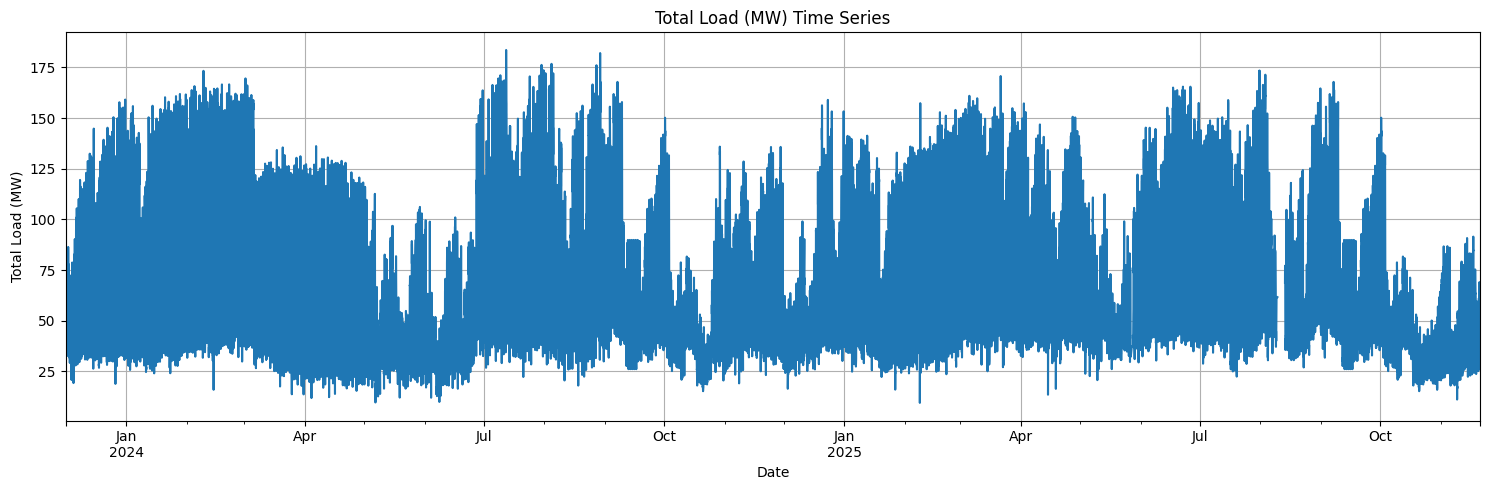

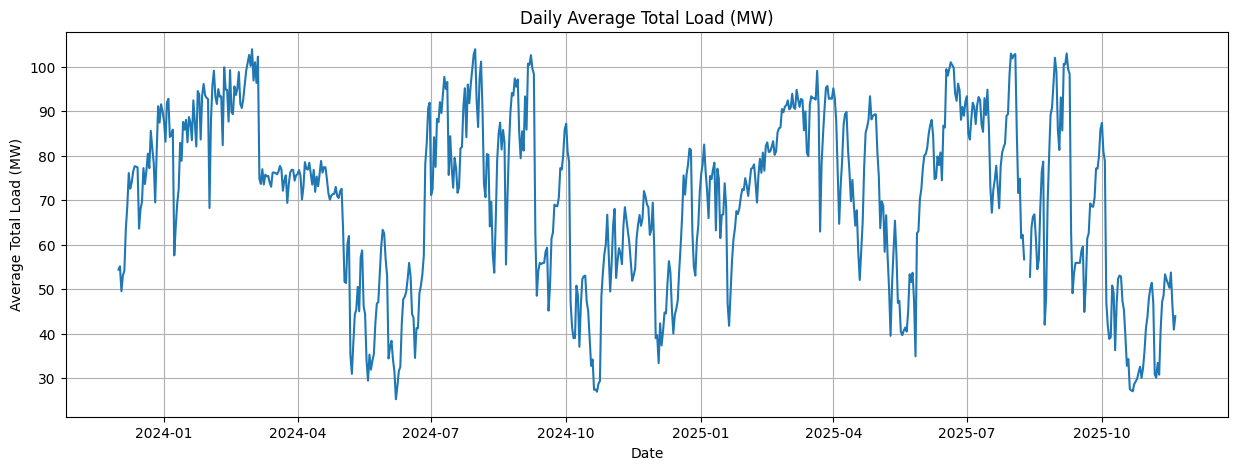

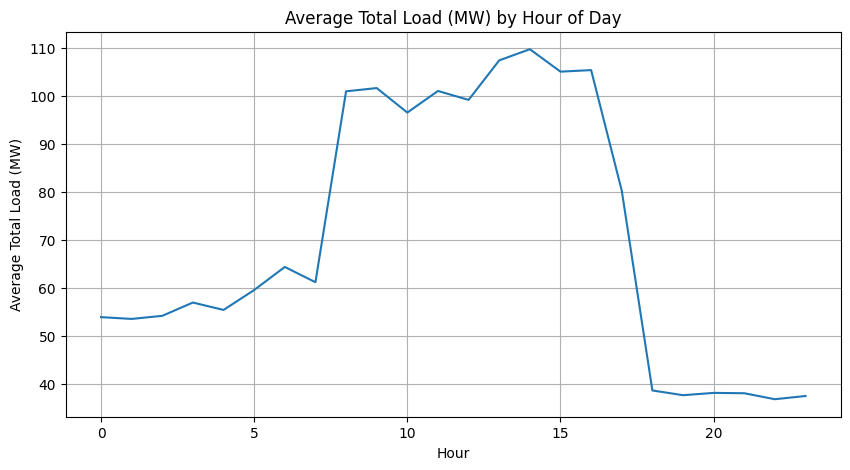

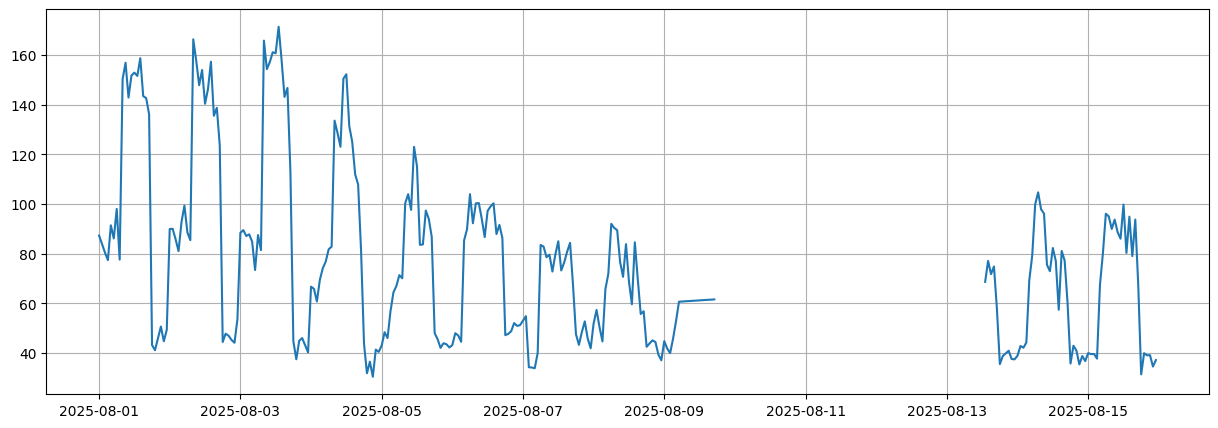

In [96]:
#1. PRE PROCESSING
#we load the dataset and convert it into a useful time series format
data = pd.read_csv('/content/Hourly_Data_220kVComma.csv') #this sheet has a column for Time and a column for MCP
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'],format='%d-%m-%Y %H:%M',errors = 'coerce')
data = data.dropna(subset=['Datetime'])
data.set_index('Datetime', inplace=True)
data = data[['Total Load (MW)']] #now we have the standard datetime time series object on which we can apply random forests
data = data.sort_index()

print(data.index.min())
print(data.index.max())
print(len(data))
#now we change the Load data type from object to numeric
data['Total Load (MW)'] = pd.to_numeric(
    data['Total Load (MW)'],
    errors='coerce')

# Remove duplicates
data = data[~data.index.duplicated(keep='first')]

# Remove known outage
mask = (
    (data.index >= '2025-08-09 06:00') &
    (data.index <= '2025-08-13 12:00')
)

data = data.loc[~mask]

# Sort
data = data.sort_index()

# Force hourly index
data = data.asfreq('h')
#this code is to find and interpolate the very small chunks of missing data
daily_count = data['Total Load (MW)'].resample('D').count()
bad_days = daily_count[daily_count < 24]
print(bad_days)

small_gap_limit = 12 #limit I have decided to be the threshold for the interpolation to apply

data['Total Load (MW)'] = (
    data['Total Load (MW)']
    .interpolate(method='time', limit=small_gap_limit))

#plotting the raw series
plt.figure(figsize=(15, 5))
data['Total Load (MW)'].plot() #automatically use datetime for the x-axis as index
plt.title('Total Load (MW) Time Series')
plt.xlabel('Date')
plt.ylabel('Total Load (MW)')
plt.grid(True)
plt.tight_layout()
plt.show()

#plotting the daily average MCP
daily = data['Total Load (MW)'].resample('D').mean()

plt.figure(figsize=(15,5))
plt.plot(daily.index, daily)
plt.title('Daily Average Total Load (MW)')
plt.xlabel('Date')
plt.ylabel('Average Total Load (MW)')
plt.grid(True)
plt.show()

#hourly average plot
hourly_avg = data.groupby(data.index.hour)['Total Load (MW)'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg)
plt.title('Average Total Load (MW) by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Total Load (MW)')
plt.grid(True)
plt.show()

subset = data.loc['2025-08-01':'2025-08-15']

plt.figure(figsize=(15,5))
plt.plot(subset.index, subset['Total Load (MW)'])
plt.grid(True)
plt.show()
#Making the target column for day ahead price forecasting, it is the MCP column shifted ahead by 1 day since we will be predicting a day ahead
# 24 intervals = 1 day
data['target'] = data['Total Load (MW)'].shift(-24)


lag_168                 168
lag_72                   72
lag_48                   48
rolling_mean_24          24
lag_24                   24
rolling_max_24           24
rolling_std_24           24
rolling_min_24           24
lag_12                   12
lag_4                     4
lag_2                     2
lag_1                     1
Total Load (MW)           0
target                    0
hour                      0
dayofweek                 0
month                     0
is_weekend                0
temperature_2m            0
relative_humidity_2m      0
precipitation             0
cloud_cover               0
wind_speed_10m            0
temp_sq                   0
rain_flag                 0
dtype: int64
(16582, 25)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 16582 entries, 2023-12-15 00:00:00 to 2025-11-19 23:00:00
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Total Load (MW)       16

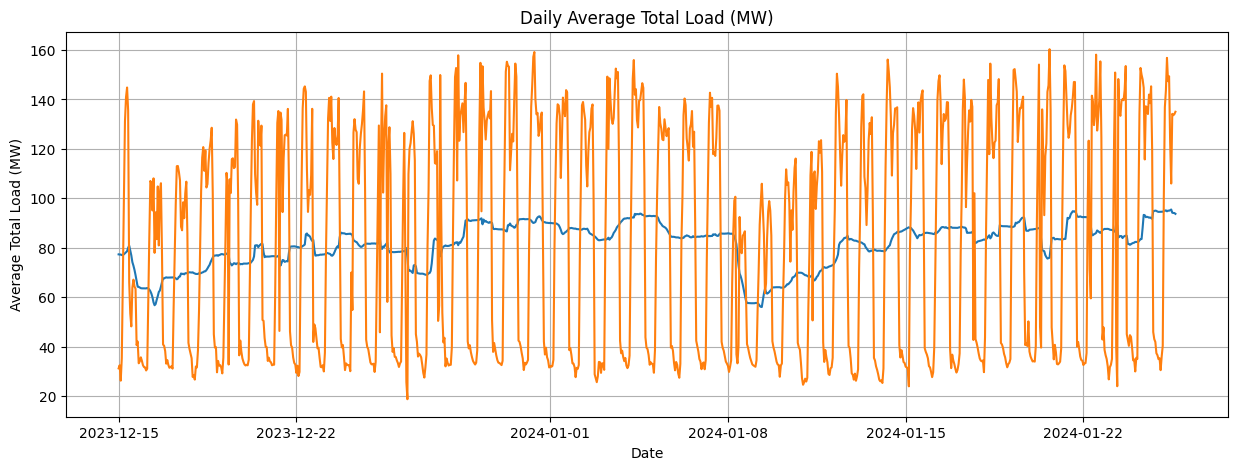

In [113]:
#2. CREATING THE FEATURES FOR OUR MODEL TO USE
#since random forests does not directly work on time series objects, we make features for it to use, the first of these is lag features

# Recent lags (I dont know how useful these will be)
data['lag_1'] = data['Total Load (MW)'].shift(1)
data['lag_2'] = data['Total Load (MW)'].shift(2)
data['lag_4'] = data['Total Load (MW)'].shift(4)

# 12 Hour ago
data['lag_12'] = data['Total Load (MW)'].shift(12)

# 24 hours ago
data['lag_24'] = data['Total Load (MW)'].shift(24)

# 2 days ago
data['lag_48'] = data['Total Load (MW)'].shift(48)

# 3 days ago
data['lag_72'] = data['Total Load (MW)'].shift(72)

# One week ago
data['lag_168'] = data['Total Load (MW)'].shift(168)

#next features I use are rolling statistics of varying windows for the mean

# Last day average
data['rolling_mean_24'] = data['Total Load (MW)'].shift(1).rolling(24).mean()

#The one below calculate rolling standard deviations for us to measure volitality
# Last day volatility
data['rolling_std_24'] = data['Total Load (MW)'].shift(1).rolling(24).std()

#These are min and max statistics
# Last day max
data['rolling_max_24'] = data['Total Load (MW)'].shift(1).rolling(24).max()

# Last day min
data['rolling_min_24'] = data['Total Load (MW)'].shift(1).rolling(24).min()

#next we make calendar features since the price heavily depends on time
data['hour'] = data.index.hour

data['dayofweek'] = data.index.dayofweek

data['month'] = data.index.month

data['is_weekend'] = (
    data.index.dayofweek >= 5
).astype(int)

#at last all those shifts created NaN values, i remove these
print(data.isna().sum().sort_values(ascending=False))
data = data.dropna() #dropping the wrong values created

print(data.shape)
print(data.info())
print(data.columns)
features = [
    'lag_1',
    'lag_12',
    'lag_24',
    'lag_48',
    'lag_168',
    'rolling_mean_24',
    'rolling_std_24',
    'hour',
    'dayofweek',
    'month'
]
plt.figure(figsize=(15,5))
plt.plot(data["rolling_mean_24"].iloc[0:1000])
plt.plot(data["Total Load (MW)"].iloc[0:1000])
plt.title('Daily Average Total Load (MW)')
plt.xlabel('Date')
plt.ylabel('Average Total Load (MW)')
plt.grid(True)
plt.show()

In [98]:
#now i split the data into three sets, training set, validation set and testing set
train = data[data.index < '2025-04-01']

val = data[
    (data.index >= '2025-04-01') &
    (data.index < '2025-08-01')
]

test = data[data.index >= '2025-08-01']

X_train = train[features]
y_train = train['target']

X_val = val[features]
y_val = val['target']

X_test = test[features]
y_test = test['target']

print(y_train.describe())
print(y_val.describe())
print(y_test.describe())

count    11520.000000
mean        71.851488
std         39.813602
min          9.420000
25%         38.117500
50%         57.435000
75%        105.862500
max        183.640000
Name: target, dtype: float64
count    2844.000000
mean       77.059539
std        36.257025
min        13.450000
25%        43.430000
50%        70.245000
75%       107.207500
max       173.510000
Name: target, dtype: float64
count    2386.000000
mean       58.730883
std        33.491740
min        11.070000
25%        35.315000
50%        47.370000
75%        74.960000
max       171.430000
Name: target, dtype: float64


In [99]:
#now comes the main work, the model training
#Im gonna use random forest regressor first as it is one of the simpler models for random forest
#Later on i will use more sophisticated models like LightGBM and XGBoost
xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,

    max_depth=6,
    min_child_weight=10,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    objective='reg:squarederror',
    random_state=42
)
xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)


[0]	validation_0-rmse:35.67966
[100]	validation_0-rmse:13.47222
[200]	validation_0-rmse:13.68906
[300]	validation_0-rmse:13.80129
[400]	validation_0-rmse:13.95217
[500]	validation_0-rmse:14.00268
[600]	validation_0-rmse:14.08136
[700]	validation_0-rmse:14.14440
[800]	validation_0-rmse:14.22589
[900]	validation_0-rmse:14.30705
[1000]	validation_0-rmse:14.37434
[1100]	validation_0-rmse:14.41179
[1200]	validation_0-rmse:14.43880
[1300]	validation_0-rmse:14.45732
[1400]	validation_0-rmse:14.52368
[1500]	validation_0-rmse:14.56550
[1600]	validation_0-rmse:14.58175
[1700]	validation_0-rmse:14.61969
[1800]	validation_0-rmse:14.65952
[1900]	validation_0-rmse:14.69054
[2000]	validation_0-rmse:14.70190
[2100]	validation_0-rmse:14.71583
[2200]	validation_0-rmse:14.74019
[2300]	validation_0-rmse:14.75634
[2400]	validation_0-rmse:14.79214
[2500]	validation_0-rmse:14.81250
[2600]	validation_0-rmse:14.82524
[2700]	validation_0-rmse:14.84253
[2800]	validation_0-rmse:14.85458
[2900]	validation_0-rmse:1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

In [100]:
#now we predict
pred = xgb.predict(X_test)

train_pred = xgb.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R² :", r2_score(y_test, pred))

Train R²: 0.9929810743363571
Test R² : 0.8525451101850893


In [101]:
mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(
    mean_squared_error(y_test, pred)
)

r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 8.257804923333346
RMSE: 12.858084443744334
R²  : 0.8525451101850893


In [102]:
#This is a very important part, we need to see which features were more important so we run a feature importance test
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance.head(20))

baseline_pred = X_test['lag_24']

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_mae = mean_absolute_error(
    y_test, baseline_pred
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

           feature  importance
2           lag_24    0.606981
3           lag_48    0.150413
0            lag_1    0.062186
9            month    0.032954
7             hour    0.030795
5  rolling_mean_24    0.029013
4          lag_168    0.026431
6   rolling_std_24    0.022514
8        dayofweek    0.021988
1           lag_12    0.016724
Baseline MAE : 11.572452849958088
Baseline RMSE: 18.608785373665558


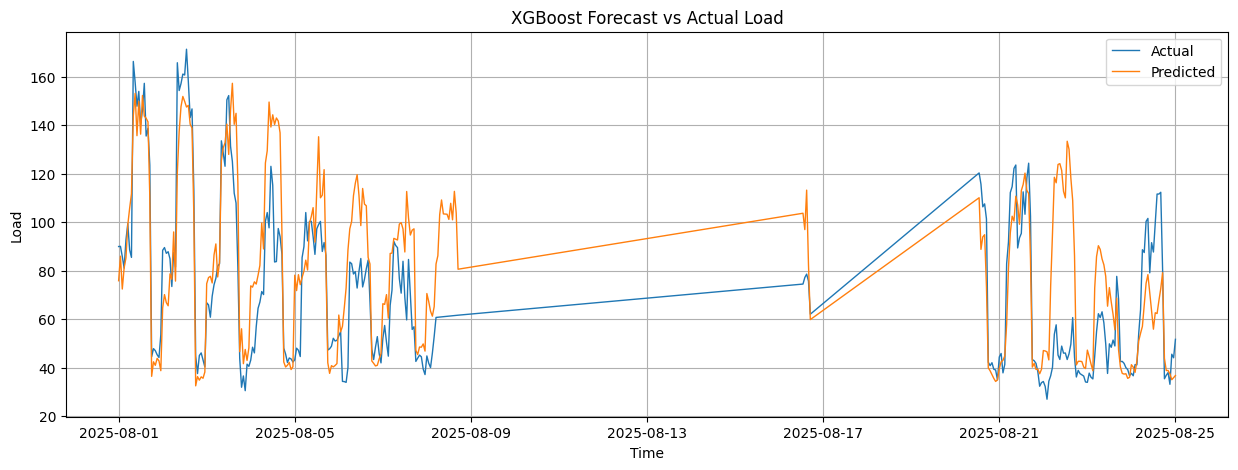

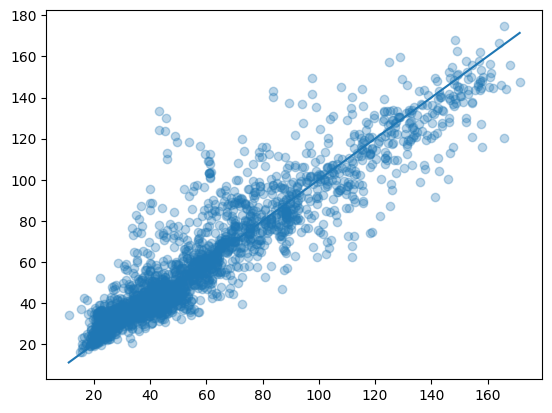

In [103]:
#I plot the actual data vs the predicted data
plt.figure(figsize=(15,5))

start_date = '2025-08-01'
end_date   = '2025-08-25'

mask = (y_test.index >= start_date) & (y_test.index <= end_date)

plt.plot(
    y_test.index[mask],
    y_test[mask],
    label='Actual',
    linewidth=1
)

plt.plot(
    y_test.index[mask],
    pred[mask],
    label='Predicted',
    linewidth=1
)

plt.legend()
plt.title("XGBoost Forecast vs Actual Load")
plt.xlabel("Time")
plt.ylabel("Load")
plt.grid(True)

plt.show()

# Predicted vs Actual
plt.scatter(y_test, pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

In [104]:
import requests

In [105]:
url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=12.75"
    "&longitude=78.34"
    "&start_date=2023-12-01"
    "&end_date=2025-11-20"
    "&hourly=temperature_2m,relative_humidity_2m,"
    "precipitation,cloud_cover,wind_speed_10m"
)

wdata = requests.get(url).json()

weather = pd.DataFrame(wdata["hourly"])

weather["time"] = pd.to_datetime(weather["time"])

weather.rename(columns={"time":"Datetime"}, inplace=True)

weather.set_index("Datetime", inplace=True)
weather = weather.sort_index()
print(data.index.tz)
print(weather.index.tz)
print(data.index.min(), data.index.max())
print(weather.index.min(), weather.index.max())
data = data.join(weather, how='left')
print(data.isna().sum())
print(data.head())

None
None
2023-12-08 00:00:00 2025-11-19 23:00:00
2023-12-01 00:00:00 2025-11-20 23:00:00
Total Load (MW)         0
target                  0
lag_1                   0
lag_2                   0
lag_4                   0
lag_12                  0
lag_24                  0
lag_48                  0
lag_72                  0
lag_168                 0
rolling_mean_24         0
rolling_std_24          0
rolling_max_24          0
rolling_min_24          0
hour                    0
dayofweek               0
month                   0
is_weekend              0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
cloud_cover             0
wind_speed_10m          0
dtype: int64
                     Total Load (MW)  target  lag_1  lag_2  lag_4  lag_12  \
Datetime                                                                    
2023-12-08 00:00:00            29.53   33.49  34.42  35.34  39.86   91.98   
2023-12-08 01:00:00            33.94   34.05  29.53  34.42  37.52   

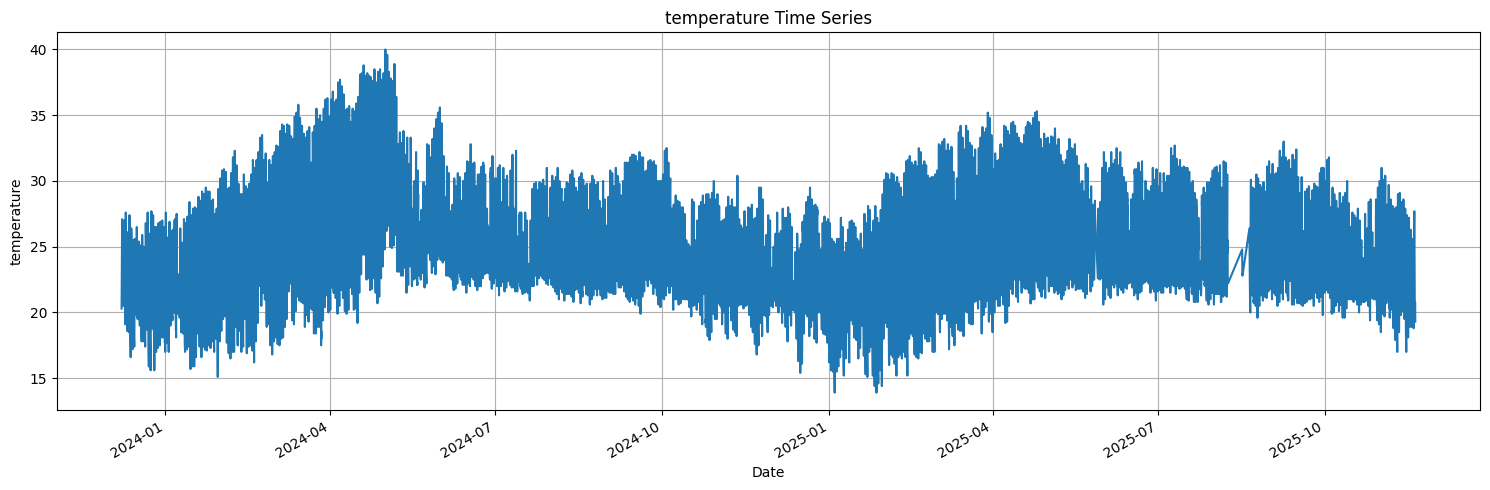

In [106]:
plt.figure(figsize=(15, 5))
data['temperature_2m'].plot() #automatically use datetime for the x-axis as index
plt.title('temperature Time Series')
plt.xlabel('Date')
plt.ylabel('temperature')
plt.grid(True)
plt.tight_layout()
plt.show()

In [107]:
#We make new weather features and load them into our feature set

#squared of temperature as feature
data['temp_sq'] = data['temperature_2m']**2

#feature for rain flagging
data['rain_flag'] = (data['precipitation'] > 0).astype(int)

features.extend(['rain_flag','temperature_2m','relative_humidity_2m'])

In [108]:
#now i split the data into three sets, training set, validation set and testing set
wtrain = data[data.index < '2025-04-01']

wval = data[
    (data.index >= '2025-04-01') &
    (data.index < '2025-08-03')
]

wtest = data[data.index >= '2025-08-25']

wX_train = wtrain[features]
wy_train = wtrain['target']

wX_val = wval[features]
wy_val = wval['target']

wX_test = wtest[features]
wy_test = wtest['target']

print(wy_train.describe())
print(wy_val.describe())
print(wy_test.describe())

count    11520.000000
mean        71.851488
std         39.813602
min          9.420000
25%         38.117500
50%         57.435000
75%        105.862500
max        183.640000
Name: target, dtype: float64
count    2892.000000
mean       77.486103
std        36.549298
min        13.450000
25%        43.592500
50%        70.615000
75%       107.695000
max       173.510000
Name: target, dtype: float64
count    2088.000000
mean       56.884066
std        33.075498
min        11.070000
25%        33.482500
50%        45.750000
75%        70.970000
max       167.890000
Name: target, dtype: float64


In [109]:
#now comes the main work, the model training
#Im gonna use random forest regressor first as it is one of the simpler models for random forest
#Later on i will use more sophisticated models like LightGBM and XGBoost
wxgb = XGBRegressor(
    n_estimators=10000,
    learning_rate=0.005,

    max_depth=10,
    min_child_weight=6,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    objective='reg:squarederror',
    random_state=42
)

#parameter dictionary for hyperparameter tuning
# param_dist = {
#     'n_estimators': [300,350,400,500,200],
#     'learning_rate': [0.01, 0.03, 0.05],

#     'max_depth': [3, 4, 5, 6],
#     'min_child_weight': [1, 3, 5, 10]
# }

# tscv = TimeSeriesSplit(n_splits=3)

# search = RandomizedSearchCV(
#     estimator=wxgb,
#     param_distributions=param_dist,
#     n_iter=50,          # start with 50
#     scoring='r2',
#     cv=tscv,
#     verbose=2,
#     random_state=42,
#     n_jobs=-1
# )

wxgb.fit(
    wX_train,
    wy_train,
    eval_set=[(wX_val, wy_val)],
    verbose=100
)

# print("Best Parameters:")
# print(search.best_params_)

# print("\nBest CV R²:")
# print(search.best_score_)

[0]	validation_0-rmse:36.81665
[100]	validation_0-rmse:24.66111
[200]	validation_0-rmse:18.22291
[300]	validation_0-rmse:15.21332
[400]	validation_0-rmse:13.96552
[500]	validation_0-rmse:13.53759
[600]	validation_0-rmse:13.43505
[700]	validation_0-rmse:13.44410
[800]	validation_0-rmse:13.45899
[900]	validation_0-rmse:13.47882
[1000]	validation_0-rmse:13.51161
[1100]	validation_0-rmse:13.54140
[1200]	validation_0-rmse:13.58481
[1300]	validation_0-rmse:13.61890
[1400]	validation_0-rmse:13.64632
[1500]	validation_0-rmse:13.68190
[1600]	validation_0-rmse:13.70591
[1700]	validation_0-rmse:13.73433
[1800]	validation_0-rmse:13.75881
[1900]	validation_0-rmse:13.79029
[2000]	validation_0-rmse:13.80432
[2100]	validation_0-rmse:13.82617
[2200]	validation_0-rmse:13.84621
[2300]	validation_0-rmse:13.86090
[2400]	validation_0-rmse:13.87822
[2500]	validation_0-rmse:13.89371
[2600]	validation_0-rmse:13.90850
[2700]	validation_0-rmse:13.92749
[2800]	validation_0-rmse:13.94153
[2900]	validation_0-rmse:1

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=6, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

In [110]:
#now we predict
# wxgb = search.best_estimator_
wpred = wxgb.predict(wX_test)

wtrain_pred = wxgb.predict(wX_train)

print("Train R²:", r2_score(wy_train, wtrain_pred))
print("Test R² :", r2_score(wy_test, wpred))

wmae = mean_absolute_error(wy_test, wpred)

wrmse = np.sqrt(
    mean_squared_error(wy_test, wpred)
)

wr2 = r2_score(wy_test, wpred)

print("MAE :", wmae)
print("RMSE:", wrmse)
print("R²  :", wr2)

Train R²: 0.9980329646314885
Test R² : 0.909460802518862
MAE : 6.874740001780777
RMSE: 9.949945342447592
R²  : 0.909460802518862


In [111]:
#This is a very important part, we need to see which features were more important so we run a feature importance test
wimportance = pd.DataFrame({
    'feature': wX_train.columns,
    'importance': wxgb.feature_importances_
})

wimportance = wimportance.sort_values(
    by='importance',
    ascending=False
)

print(wimportance.head(20))

wbaseline_pred = wX_test['lag_24']

wbaseline_rmse = np.sqrt(
    mean_squared_error(wy_test, wbaseline_pred)
)

wbaseline_mae = mean_absolute_error(
    wy_test, wbaseline_pred
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

                 feature  importance
2                 lag_24    0.586963
3                 lag_48    0.130052
0                  lag_1    0.058351
10             rain_flag    0.035829
4                lag_168    0.029264
9                  month    0.028868
7                   hour    0.028114
5        rolling_mean_24    0.025189
12  relative_humidity_2m    0.017933
6         rolling_std_24    0.017682
8              dayofweek    0.015170
11        temperature_2m    0.013561
1                 lag_12    0.013025
Baseline MAE : 11.572452849958088
Baseline RMSE: 18.608785373665558


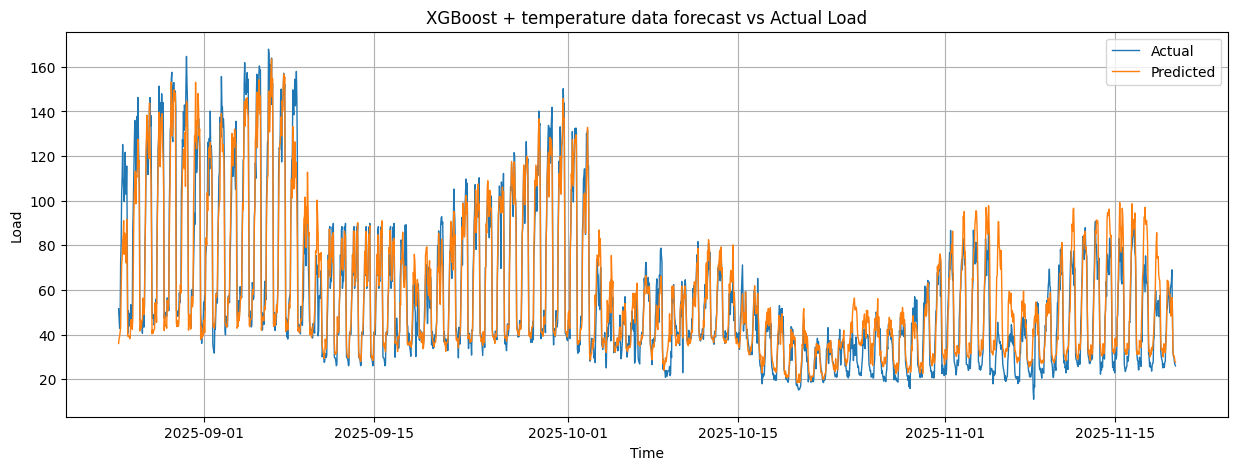

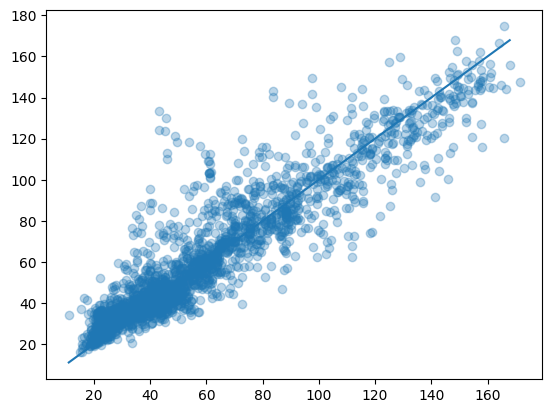

In [112]:
#I plot the actual data vs the predicted data
plt.figure(figsize=(15,5))

plt.plot(
    wy_test.index,
    wy_test,
    label='Actual',
    linewidth=1
)

plt.plot(
    wy_test.index,
    wpred,
    label='Predicted',
    linewidth=1
)

plt.legend()
plt.title("XGBoost + temperature data forecast vs Actual Load")
plt.xlabel("Time")
plt.ylabel("Load")
plt.grid(True)

plt.show()

# Predicted vs Actual
plt.scatter(y_test, pred, alpha=0.3)
plt.plot(
    [wy_test.min(), wy_test.max()],
    [wy_test.min(), wy_test.max()]
)